# Analisis de `phot_df`/`head_df` -- LightCurveLynx vs SNANA (Fase 17)

Notebook de analisis para las tablas crudas (`head_df.parquet`/`phot_df.parquet`) que escriben
`run_simsed_poc.py`, `run_non1ased_poc.py` y `run_snia_ddf_poc.py` (ver `NOTES.md` Fase 5 y Fase 17).
Antes de esta fase, el pipeline solo dejaba en disco las imagenes QC y el `summary.json` agregado --
este notebook trabaja directo con la fotometria simulada objeto por objeto.

**Estado de los datos al momento de escribir este notebook** (ver `NOTES.md` Fase 17): se liberaron
~14.6GB de NLHPC borrando la mayoria de los `phot_df.parquet` ya usados (se conserva `summary.json`
como "comprobacion"), y los 3 scripts `run_*_poc.py` ya soportan un flag `--wfd` para correr a escala
WFD (ver `wfd_mwebv_grid.csv` / `snana_params.make_wfd_ebv_lookup`) -- **pero la campana WFD no se
lanzo en esta sesion** (decision explicita del usuario, cuota de NLHPC sigue fragil). Este notebook
detecta automaticamente que corridas hay disponibles cada vez que se ejecuta: funciona hoy con lo que
ya existe (principalmente `head_df.parquet`, algun `phot_df.parquet` suelto) y se completa solo, sin
editar nada, el dia que se corra `--wfd` o se regenere algun `phot_df.parquet` de DDF.

Ejecutar dentro del venv de NLHPC (`~/AUTOSIM/exploration/lightcurvelynx/venv`, tiene `pandas`/
`pyarrow`/`matplotlib`/`jupyter` -- instalado en Fase 17, antes solo tenia las librerias de simulacion,
no las de notebook), nunca en el login node para las celdas que lean archivos grandes.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if not list(HERE.glob("poc_output*")):
    # soporta correr el notebook desde otro cwd (p.ej. jupyter lab abierto
    # en la raiz del repo) -- cae al directorio real del proyecto.
    HERE = Path("/home/mvalenzuela/AUTOSIM/exploration/lightcurvelynx")
print(f"directorio de datos: {HERE}")

directorio de datos: /home/mvalenzuela/AUTOSIM/exploration/lightcurvelynx


## Glosario rapido de columnas

(version condensada del glosario completo del dashboard, `docs/index.html` seccion 06 -- ver ahi para
la lista completa con ~40 terminos organizados por categoria)

**`summary.json`** (uno por corrida/carpeta `poc_output_*`):
- `class_key`: clave de la clase de transiente (p.ej. `SLSN-I`, `SNIa-91bg-elastic`).
- `strategy`: `DDF` (Deep Drilling Fields, 6 campos fijos) o `WFD` (Wide Fast Deep, footprint amplio
  sin campos fijos) -- campo nuevo de Fase 17, ausente en `summary.json` generados antes (se asume
  `DDF`, unica estrategia que existia hasta ahora).
- `ngentot_lc`: NGENTOT real (numero de objetos generados, no solo detectados).
- `n_with_obs`: objetos con al menos una observacion real dentro del footprint/cadencia.
- `n_detected`: objetos que pasaron el trigger SEARCHEFF real (>= N epocas reales, ver `searcheff.py`).
- `detection_efficiency_pct`: `100 * n_detected / ngentot_lc`.
- `snr_median`/`snr_p90`: percentiles de SNR simulado (`FLUXCAL/FLUXCALERR`), TODAS las observaciones
  (no solo las detectadas) -- metrica de diagnostico usada desde Fase 1 para comparar el ruido
  fotometrico de LightCurveLynx contra SNANA real.

**`head_df.parquet`** (una fila por objeto simulado con al menos una observacion):
- `SNID`: id del objeto (entero como string, convencion SNANA).
- `SNTYPE`: codigo numerico de tipo de transiente real de SNANA (no arbitrario, ver `NON1A_KEYS`).
- `RA`/`DEC`: posicion real (grados) -- para DDF cae en uno de los 6 campos, para WFD en cualquier
  parte del footprint real de observacion.
- `REDSHIFT_HELIO`: redshift heliocentrico simulado.
- `PEAKMJD`: MJD del pico de brillo (t0 del modelo).
- `NOBS`: numero de observaciones (epocas) reales que cayeron sobre este objeto.
- `DETECTED`: booleano, si paso el trigger SEARCHEFF (mismo criterio que `n_detected` de arriba).

**`phot_df.parquet`** (una fila por observacion individual, muchas por objeto):
- `SNID`: id del objeto (FK a `head_df`).
- `MJD`: fecha juliana modificada de la observacion.
- `FLT`: filtro/banda real de LSST (`u,g,r,i,z,Y`).
- `FLUXCAL`/`FLUXCALERR`: flujo y su error, en nJy (no el `FLUXCAL`/ZEROPT=27.5 de SNANA -- ver
  conversion `MAG_AB_ZP_NJY` en los scripts `run_*_poc.py`).
- `MAG`: magnitud AB derivada de `FLUXCAL` (solo valida donde `FLUXCAL>0`, si no `NaN`).
- `PHOTFLAG`: `4096` si esa observacion individual paso el corte de eficiencia de deteccion
  (`SEARCHEFF`), `0` si no -- distinto de `DETECTED` en `head_df`, que es a nivel de objeto
  (>= N epocas con `PHOTFLAG=4096`), no de observacion individual.

## 1. Inventario de corridas disponibles

Escanea todas las carpetas `poc_output_*` reales (no asume una lista fija de clases) y arma una tabla
con lo que SI existe hoy en disco -- esto es lo que determina que celdas de abajo van a tener datos
para trabajar y cuales van a mostrar un aviso de "no encontrado" en vez de fallar.

In [2]:
rows = []
for d in sorted(HERE.glob("poc_output*")):
    if not d.is_dir():
        continue
    summary_path = d / "summary.json"
    if not summary_path.exists():
        continue  # carpeta sin ninguna corrida real completada
    summary = json.loads(summary_path.read_text())
    rows.append({
        "dir": d.name,
        "class_key": summary.get("class_key", d.name),
        "model_class": summary.get("model_class", "SIMSED/SALT2"),
        # summary.json generados antes de Fase 17 no tienen "strategy" --
        # toda corrida anterior a esta fase era DDF (unica estrategia que
        # existia), asi que ese es el default correcto, no una adivinanza.
        "strategy": summary.get("strategy", "DDF"),
        "seed_index": summary.get("seed_index", 0),
        "ngentot_lc": summary.get("ngentot_lc"),
        "n_with_obs": summary.get("n_with_obs"),
        "n_detected": summary.get("n_detected"),
        "detection_efficiency_pct": summary.get("detection_efficiency_pct"),
        "snr_median": summary.get("snr_median"),
        "snr_p90": summary.get("snr_p90"),
        "has_head_df": (d / "head_df.parquet").exists(),
        "has_phot_df": (d / "phot_df.parquet").exists(),
    })

inventory = pd.DataFrame(rows)
print(f"{len(inventory)} corridas con summary.json encontradas "
      f"({inventory['has_head_df'].sum()} con head_df.parquet, "
      f"{inventory['has_phot_df'].sum()} con phot_df.parquet)")
inventory.sort_values(["class_key", "strategy", "seed_index"]).reset_index(drop=True)

106 corridas con summary.json encontradas (25 con head_df.parquet, 1 con phot_df.parquet)


,dir,class_key,model_class,strategy,seed_index,ngentot_lc,n_with_obs,n_detected,detection_efficiency_pct,snr_median,snr_p90,has_head_df,has_phot_df
0,poc_output_cart,CaRT,SIMSED/SALT2,DDF,0,2000,1998,176,8.80,0.683538,1.679991,True,False
1,poc_output_cart_seed1,CaRT,SIMSED/SALT2,DDF,1,2000,1996,182,9.10,0.680689,1.664824,False,False
2,poc_output_cart_seed2,CaRT,SIMSED/SALT2,DDF,2,2000,1997,158,7.90,0.681821,1.668660,False,False
3,poc_output_cart_seed3,CaRT,SIMSED/SALT2,DDF,3,2000,1993,163,8.15,0.680385,1.665717,False,False
4,poc_output_cart_seed4,CaRT,SIMSED/SALT2,DDF,4,2000,1997,187,9.35,0.681550,1.669353,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,poc_output_91bg,poc_output_91bg,SIMSED/SALT2,DDF,0,2000,1987,993,49.65,0.890092,3.231839,False,False
102,poc_output_seed1,poc_output_seed1,SIMSED/SALT2,DDF,1,2000,1996,1196,59.80,NaN,NaN,True,False
103,poc_output_seed2,poc_output_seed2,SIMSED/SALT2,DDF,2,2000,1994,1157,57.85,NaN,NaN,True,False
104,poc_output_seed3,poc_output_seed3,SIMSED/SALT2,DDF,3,2000,1994,1154,57.70,NaN,NaN,True,False


## 2. Eficiencia de deteccion por clase (todas las corridas con `summary.json`)

No depende de `phot_df.parquet` -- funciona con cualquier corrida que haya terminado, incluidas las
de semilla (`_seed1..4`) a las que Fase 17 les borro el `phot_df.parquet`/`head_df.parquet` crudo
(conservan `summary.json`, que es toda la "comprobacion" que hace falta para este grafico).

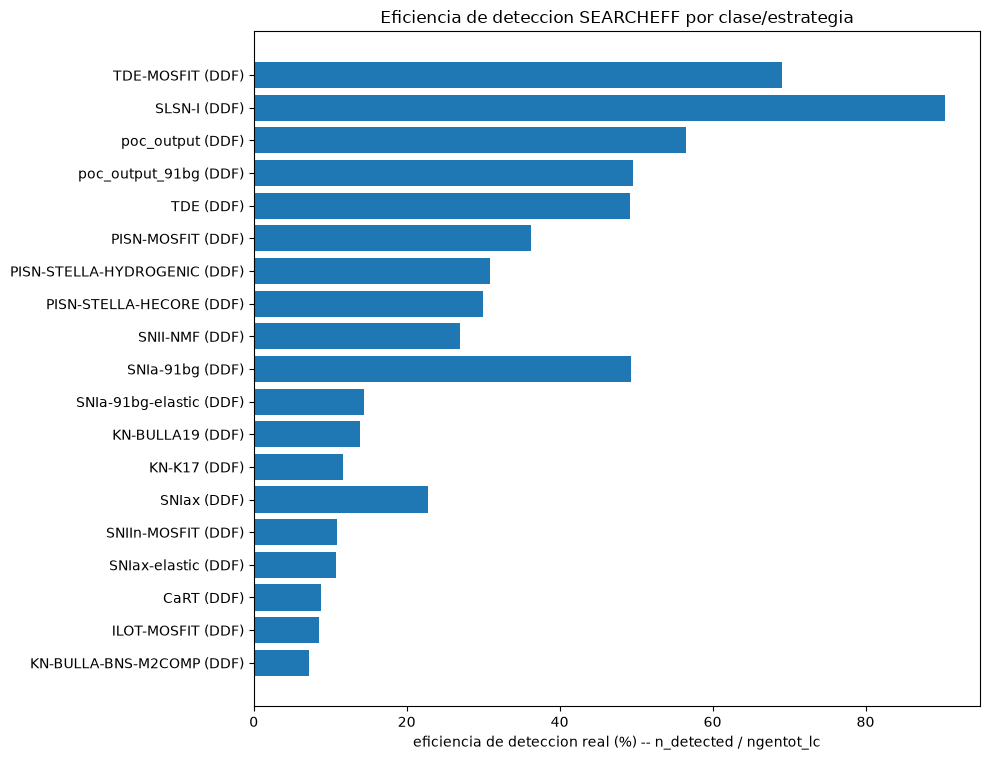

In [3]:
main_runs = inventory[inventory["seed_index"] == 0].copy()
if main_runs.empty:
    print("no hay corridas 'semilla 0' con summary.json -- nada que graficar todavia.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(main_runs))))
    colors = main_runs["strategy"].map({"DDF": "tab:blue", "WFD": "tab:orange"}).fillna("tab:gray")
    order = main_runs.sort_values("detection_efficiency_pct")
    ax.barh(order["class_key"] + " (" + order["strategy"] + ")",
            order["detection_efficiency_pct"], color=colors[order.index])
    ax.set_xlabel("eficiencia de deteccion real (%) -- n_detected / ngentot_lc")
    ax.set_title("Eficiencia de deteccion SEARCHEFF por clase/estrategia")
    plt.tight_layout()
    plt.show()

## 3. `head_df`: distribucion de redshift y NOBS por clase

Carga `head_df.parquet` de todas las corridas 'semilla 0' que lo tengan (borrado para las de semilla
extra en Fase 17 -- ver Paso 1 de `NOTES.md`) y concatena con `class_key`/`strategy` como columnas
extra para poder comparar entre clases/estrategias en el mismo grafico.

In [4]:
head_frames = []
for _, row in main_runs[main_runs["has_head_df"]].iterrows():
    h = pd.read_parquet(HERE / row["dir"] / "head_df.parquet")
    h["class_key"] = row["class_key"]
    h["strategy"] = row["strategy"]
    head_frames.append(h)

if not head_frames:
    print("ninguna corrida tiene head_df.parquet disponible ahora mismo -- "
          "correr al menos una clase (con o sin --wfd) antes de usar esta seccion.")
    head_all = pd.DataFrame()
else:
    head_all = pd.concat(head_frames, ignore_index=True)
    print(f"{len(head_all)} objetos con obs, de {head_all['class_key'].nunique()} clases")
    head_all.head()

59863 objetos con obs, de 18 clases


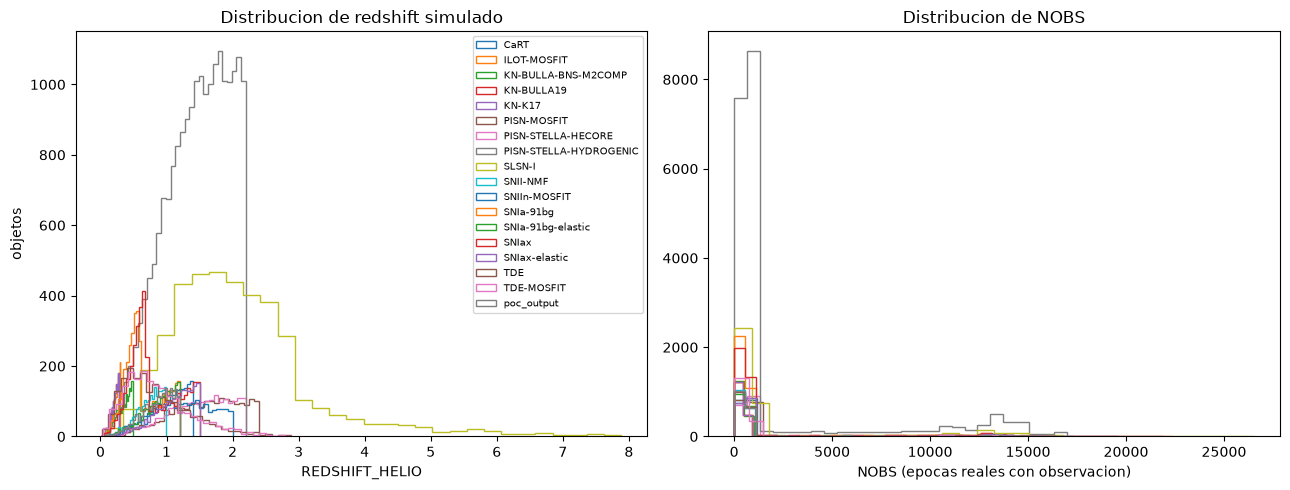

In [5]:
if not head_all.empty:
    classes = sorted(head_all["class_key"].unique())
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for c in classes:
        sub = head_all[head_all["class_key"] == c]
        axes[0].hist(sub["REDSHIFT_HELIO"], bins=30, histtype="step", label=c)
        axes[1].hist(sub["NOBS"], bins=30, histtype="step", label=c)
    axes[0].set_xlabel("REDSHIFT_HELIO"); axes[0].set_ylabel("objetos")
    axes[0].set_title("Distribucion de redshift simulado")
    axes[1].set_xlabel("NOBS (epocas reales con observacion)")
    axes[1].set_title("Distribucion de NOBS")
    axes[0].legend(fontsize=7, ncol=1)
    plt.tight_layout()
    plt.show()

## 4. Eficiencia de deteccion vs. redshift (binned)

Usa directamente la columna `DETECTED` de `head_df` (no necesita `phot_df.parquet`) -- mismo tipo de
binning ya usado en las Fases 11/13 del proyecto para diagnosticar donde se concentra la brecha
LightCurveLynx-vs-SNANA en funcion del redshift.

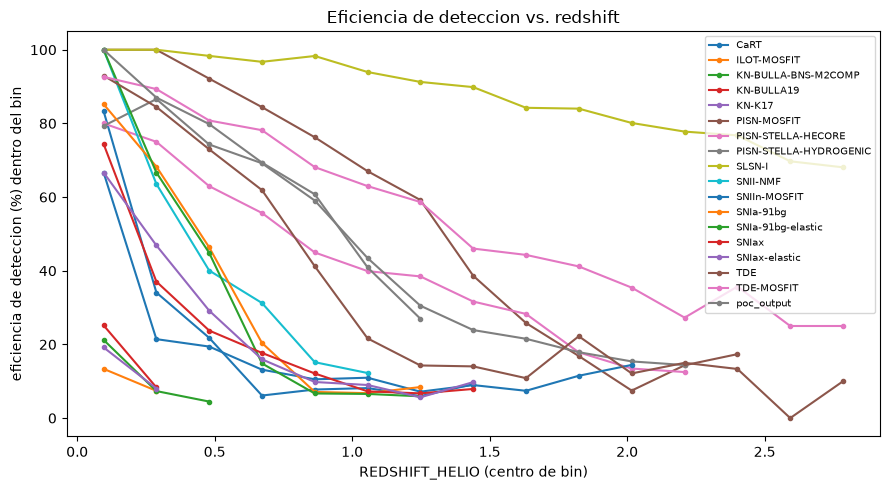

In [6]:
if not head_all.empty:
    z_bins = np.linspace(0, head_all["REDSHIFT_HELIO"].quantile(0.99), 16)
    fig, ax = plt.subplots(figsize=(9, 5))
    for c in classes:
        sub = head_all[head_all["class_key"] == c].copy()
        sub["z_bin"] = pd.cut(sub["REDSHIFT_HELIO"], z_bins)
        eff = sub.groupby("z_bin", observed=True)["DETECTED"].mean() * 100
        centers = [iv.mid for iv in eff.index]
        ax.plot(centers, eff.to_numpy(), marker="o", ms=3, label=c)
    ax.set_xlabel("REDSHIFT_HELIO (centro de bin)")
    ax.set_ylabel("eficiencia de deteccion (%) dentro del bin")
    ax.set_title("Eficiencia de deteccion vs. redshift")
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

## 5. `phot_df`: SNR simulado y cobertura de bandas

Esta seccion SI necesita `phot_df.parquet` (fotometria observacion por observacion) -- se salta con un
aviso, sin fallar, para cualquier clase que solo tenga `summary.json`/`head_df.parquet` (que es la
mayoria ahora mismo tras la limpieza de disco de Fase 17, ver Paso 1 en `NOTES.md`).

In [7]:
phot_runs = main_runs[main_runs["has_phot_df"]]
if phot_runs.empty:
    print("ninguna corrida tiene phot_df.parquet disponible ahora mismo (se libero espacio en "
          "Fase 17 borrando la mayoria) -- correr de nuevo run_simsed_poc.py/run_non1ased_poc.py/"
          "run_snia_ddf_poc.py (con o sin --wfd) para poblar esta seccion.")
else:
    for _, row in phot_runs.iterrows():
        p = pd.read_parquet(HERE / row["dir"] / "phot_df.parquet")
        snr = (p["FLUXCAL"] / p["FLUXCALERR"]).abs()
        band_counts = p["FLT"].value_counts().sort_index()
        print(f"--- {row['class_key']} ({row['strategy']}) --- "
              f"{len(p):,} obs, SNR mediana={snr.median():.3f} p90={snr.quantile(0.9):.3f}")
        print("  cobertura de bandas:", dict(band_counts))

--- poc_output (DDF) --- 3,807,528 obs, SNR mediana=0.868 p90=2.948
  cobertura de bandas: {'Y': np.int64(405192), 'g': np.int64(228419), 'i': np.int64(1231041), 'r': np.int64(524187), 'u': np.int64(321414), 'z': np.int64(1097275)}


## 6. Ejemplo de curvas de luz reales

Un par de objetos brillantes/detectados de la primera corrida con `phot_df.parquet` disponible --
mismo criterio que el panel `lightcurves.png` de `pipeline/postproc/qc.py` (objetos mas brillantes,
no una muestra al azar, ver `NOTES.md` "QC lightcurve panel").

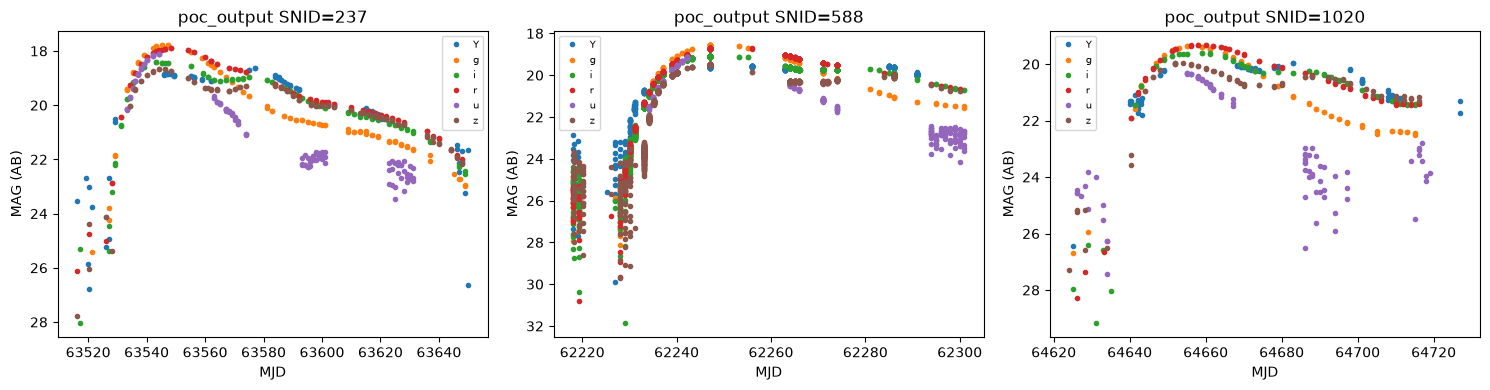

In [8]:
if not phot_runs.empty:
    example_row = phot_runs.iloc[0]
    p = pd.read_parquet(HERE / example_row["dir"] / "phot_df.parquet")
    h = pd.read_parquet(HERE / example_row["dir"] / "head_df.parquet") if example_row["has_head_df"] else None
    detected_ids = h[h["DETECTED"]]["SNID"] if h is not None else p["SNID"].unique()
    # los objetos con mayor SNR mediano son los mas brillantes/limpios para graficar.
    snr_by_obj = (p[p["SNID"].isin(detected_ids)]
                  .assign(snr=lambda d: (d["FLUXCAL"] / d["FLUXCALERR"]).abs())
                  .groupby("SNID")["snr"].median().sort_values(ascending=False))
    example_ids = snr_by_obj.head(3).index

    fig, axes = plt.subplots(1, len(example_ids), figsize=(5 * len(example_ids), 4), squeeze=False)
    for ax, snid in zip(axes[0], example_ids):
        obj = p[p["SNID"] == snid].sort_values("MJD")
        for flt, sub in obj.groupby("FLT"):
            ax.errorbar(sub["MJD"], sub["MAG"], fmt="o", ms=3, label=flt)
        ax.invert_yaxis()  # convencion de magnitud: mas brillante = numero mas chico
        ax.set_title(f"{example_row['class_key']} SNID={snid}")
        ax.set_xlabel("MJD"); ax.set_ylabel("MAG (AB)")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("sin phot_df.parquet disponible -- ver seccion 5.")

## 7. DDF vs. WFD (comparacion automatica cuando ambas existan)

Compara `detection_efficiency_pct`/`snr_median`/`snr_p90` entre estrategias para cada `class_key` que
tenga AMBAS corridas (`DDF` y `WFD`) -- funciona sola en cuanto se lance al menos una clase con
`--wfd` (ver Fase 17 en `NOTES.md`: scripts listos, campana no lanzada en esta sesion por decision
explicita del usuario), sin tener que tocar este notebook.

In [9]:
pivot = main_runs.pivot_table(
    index="class_key", columns="strategy",
    values=["detection_efficiency_pct", "snr_median", "snr_p90"],
)
both = pivot.dropna(subset=[("detection_efficiency_pct", "DDF"), ("detection_efficiency_pct", "WFD")]) \
    if ("WFD" in main_runs["strategy"].unique()) else pd.DataFrame()

if both.empty:
    n_wfd = int((main_runs["strategy"] == "WFD").sum())
    print(f"todavia no hay ninguna clase con corridas DDF y WFD a la vez "
          f"({n_wfd} corridas WFD encontradas ahora mismo) -- correr, por ejemplo:\n"
          f"  python3 run_simsed_poc.py SNIa-91bg-elastic --wfd\n"
          f"desde un job sbatch, y volver a ejecutar este notebook.")
else:
    both

todavia no hay ninguna clase con corridas DDF y WFD a la vez (0 corridas WFD encontradas ahora mismo) -- correr, por ejemplo:
  python3 run_simsed_poc.py SNIa-91bg-elastic --wfd
desde un job sbatch, y volver a ejecutar este notebook.
